First 5 rows:
      Model  Year         Region  Color Fuel_Type Transmission  Engine_Size_L  \
0  5 Series  2016           Asia    Red    Petrol       Manual            3.5   
1        i8  2013  North America    Red    Hybrid    Automatic            1.6   
2  5 Series  2022  North America   Blue    Petrol    Automatic            4.5   
3        X3  2024    Middle East   Blue    Petrol    Automatic            1.7   
4  7 Series  2020  South America  Black    Diesel       Manual            2.1   

   Mileage_KM  Price_USD  Sales_Volume Sales_Classification  
0      151748      98740          8300                 High  
1      121671      79219          3428                  Low  
2       10991     113265          6994                  Low  
3       27255      60971          4047                  Low  
4      122131      49898          3080                  Low  

Dataset columns:
Index(['Model', 'Year', 'Region', 'Color', 'Fuel_Type', 'Transmission',
       'Engine_Size_L', 'Mileage_KM',

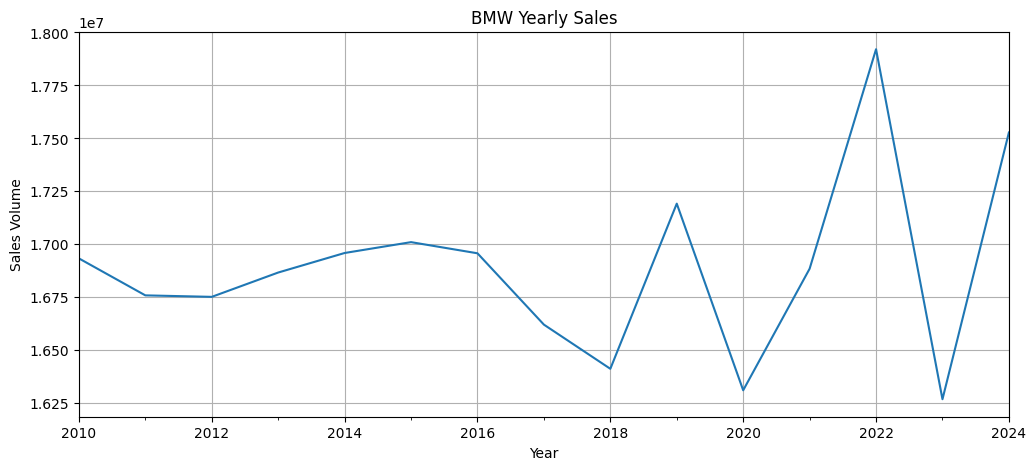


Scaled data:
Year
2010-01-01    0.402345
2011-01-01    0.296731
2012-01-01    0.292467
2013-01-01    0.361969
2014-01-01    0.417787
2015-01-01    0.448803
2016-01-01    0.416934
2017-01-01    0.213132
2018-01-01    0.086921
2019-01-01    0.558801
2020-01-01    0.025534
2021-01-01    0.372823
2022-01-01    1.000000
2023-01-01    0.000000
2024-01-01    0.762093
Freq: YS-JAN, dtype: float64


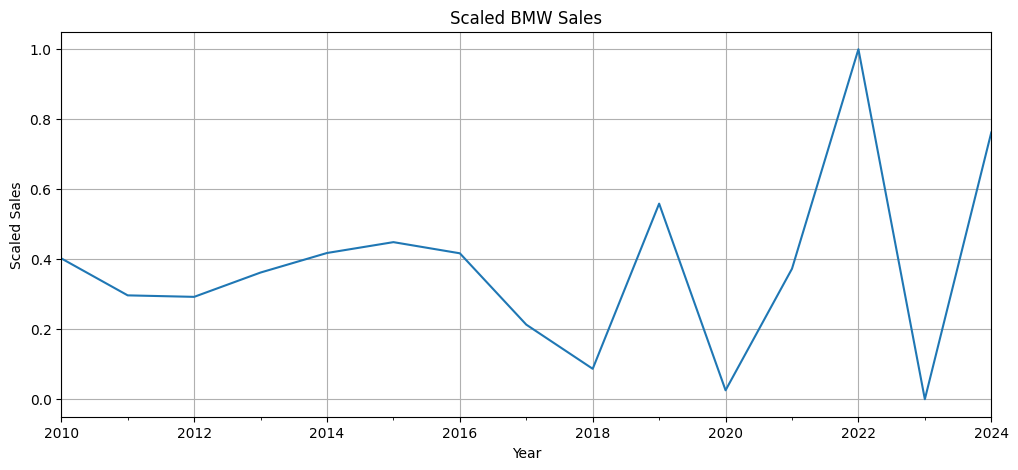

<Figure size 1200x800 with 0 Axes>

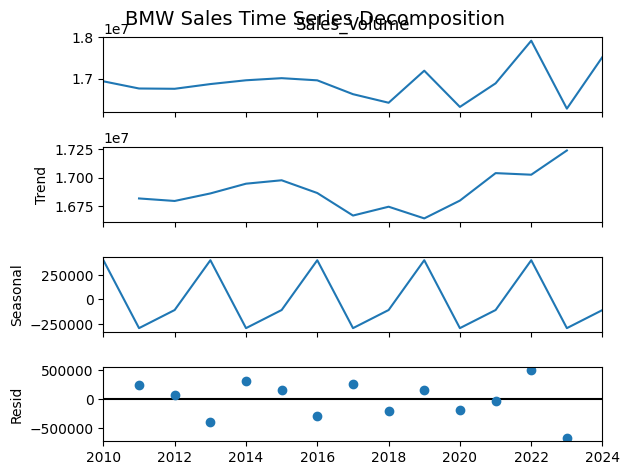


Positive scaled data:
Year
2010-01-01    1.402345
2011-01-01    1.296731
2012-01-01    1.292467
2013-01-01    1.361969
2014-01-01    1.417787
2015-01-01    1.448803
2016-01-01    1.416934
2017-01-01    1.213132
2018-01-01    1.086921
2019-01-01    1.558801
2020-01-01    1.025534
2021-01-01    1.372823
2022-01-01    2.000000
2023-01-01    1.000000
2024-01-01    1.762093
Freq: YS-JAN, dtype: float64

Training data:
Year
2010-01-01    1.402345
2011-01-01    1.296731
2012-01-01    1.292467
2013-01-01    1.361969
2014-01-01    1.417787
2015-01-01    1.448803
2016-01-01    1.416934
2017-01-01    1.213132
2018-01-01    1.086921
2019-01-01    1.558801
2020-01-01    1.025534
2021-01-01    1.372823
Freq: YS-JAN, dtype: float64

Testing data:
Year
2022-01-01    2.000000
2023-01-01    1.000000
2024-01-01    1.762093
Freq: YS-JAN, dtype: float64

Model fitted successfully.

Test Predictions:
2022-01-01    1.388229
2023-01-01    1.200025
2024-01-01    1.258419
Freq: YS-JAN, dtype: float64


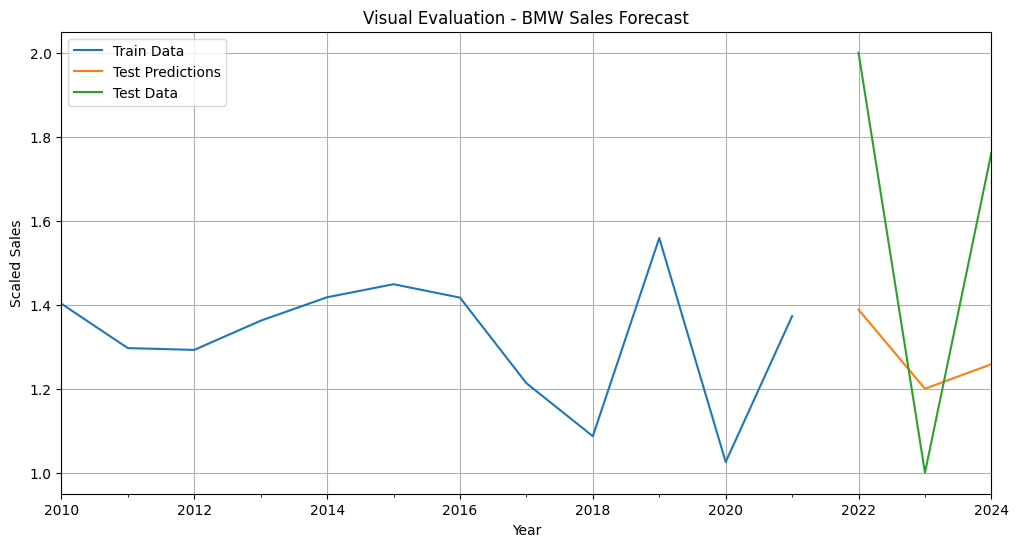


MODEL EVALUATION
MAE : 0.4384897579257189
MSE : 0.22265357399386013
RMSE: 0.471861816630526

DATA STATISTICS
Standard Deviation: 0.2630889821860611
Mean: 1.3770892796188567

Final model fitted successfully.

FUTURE FORECAST
2025-01-01    2.116784
2026-01-01    1.074795
2027-01-01    1.560181
2028-01-01    2.198275
2029-01-01    1.115648
Freq: YS-JAN, dtype: float64


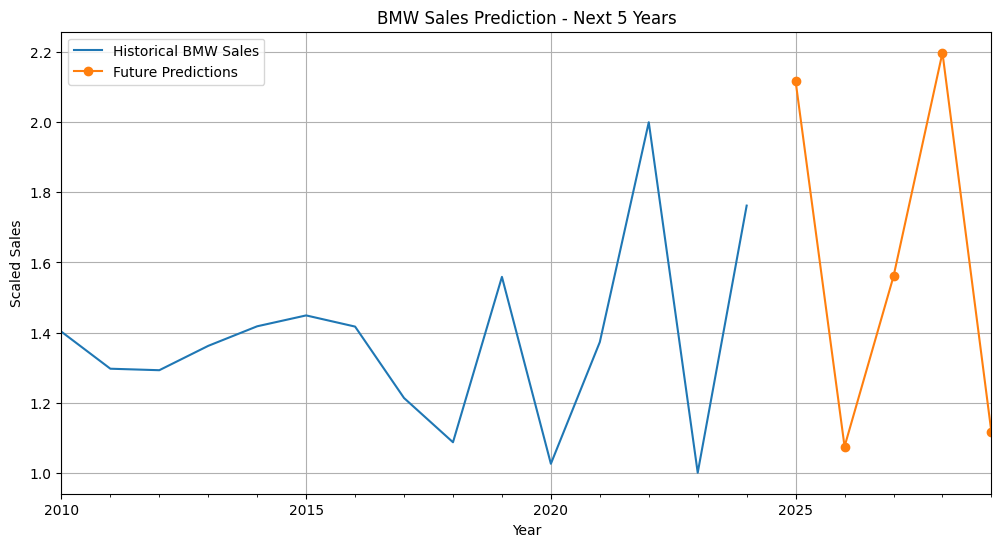


BMW SALES FORECAST
   Year  Predicted Sales Volume
0  2025            1.811391e+07
1  2026            1.639224e+07
2  2027            1.719424e+07
3  2028            1.824855e+07
4  2029            1.645974e+07


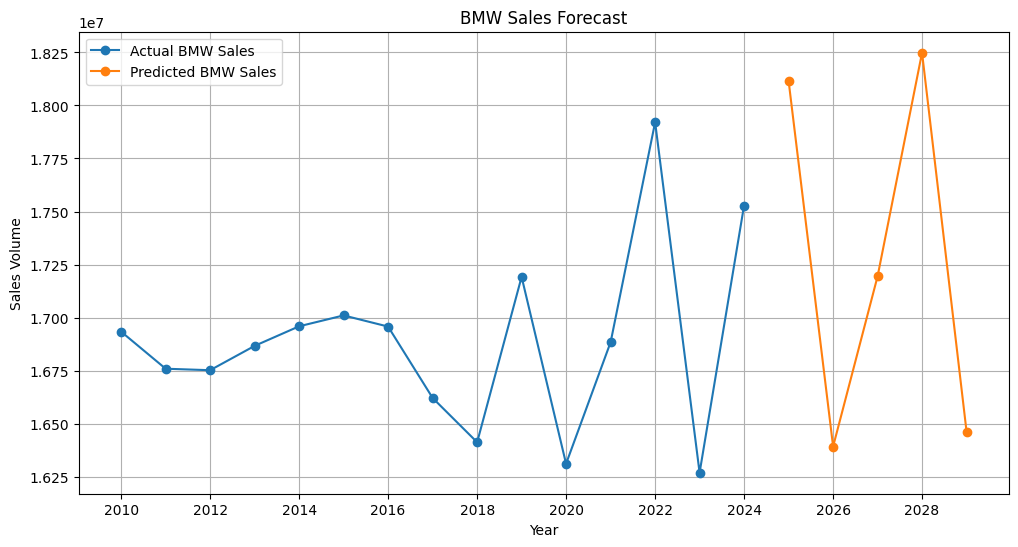


Forecast saved as BMW_sales_forecast.csv


In [13]:
# ============================================================
# BMW SALES TIME SERIES FORECASTING
# ============================================================

# 1. IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.seasonal import seasonal_decompose

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error


# ============================================================
# 2. LOAD DATASET
# ============================================================

data = pd.read_csv('/content/BMW sales data (2010-2024).csv')

print("First 5 rows:")
print(data.head())

print("\nDataset columns:")
print(data.columns)


# ============================================================
# 3. CHECK MISSING VALUES
# ============================================================

print("\nMissing values:")
print(data.isnull().sum())


# ============================================================
# 4. CREATE YEARLY SALES DATA
# ============================================================

# Sum Sales_Volume for each year
data_yearly = data.groupby('Year')['Sales_Volume'].sum()

# Convert Year into datetime index
data_yearly.index = pd.to_datetime(
    data_yearly.index.astype(str),
    format='%Y'
)

# Set yearly frequency
data_yearly = data_yearly.asfreq('YS')

print("\nYearly BMW Sales:")
print(data_yearly)


# ============================================================
# 5. PLOT ORIGINAL YEARLY DATA
# ============================================================

plt.figure(figsize=(12, 5))

data_yearly.plot()

plt.title('BMW Yearly Sales')
plt.xlabel('Year')
plt.ylabel('Sales Volume')
plt.grid(True)

plt.show()


# ============================================================
# 6. MIN-MAX SCALING
# ============================================================

scaler = MinMaxScaler()

scaled_data = pd.Series(
    scaler.fit_transform(
        data_yearly.values.reshape(-1, 1)
    ).flatten(),
    index=data_yearly.index
)

print("\nScaled data:")
print(scaled_data)


# ============================================================
# 7. PLOT SCALED DATA
# ============================================================

plt.figure(figsize=(12, 5))

scaled_data.plot()

plt.title('Scaled BMW Sales')
plt.xlabel('Year')
plt.ylabel('Scaled Sales')
plt.grid(True)

plt.show()


# ============================================================
# 8. SEASONAL DECOMPOSITION
# ============================================================

# BMW data is yearly, so there is no monthly seasonality.
# Period=3 is used only to demonstrate decomposition.

decomposition = seasonal_decompose(
    data_yearly,
    model='additive',
    period=3
)

plt.figure(figsize=(12, 8)) # Moved figsize here
decomposition.plot()

plt.suptitle(
    'BMW Sales Time Series Decomposition',
    fontsize=14
)

plt.show()


# ============================================================
# 9. SHIFT DATA FOR MULTIPLICATIVE MODEL
# ============================================================

# Multiplicative Holt-Winters requires positive values.
# Min-Max scaled values contain 0, so add 1.

scaled_data_positive = scaled_data + 1

print("\nPositive scaled data:")
print(scaled_data_positive)


# ============================================================
# 10. TRAIN-TEST SPLIT
# ============================================================

# Use 80% for training and 20% for testing

split_point = int(len(scaled_data_positive) * 0.8)

train_data = scaled_data_positive.iloc[:split_point]

test_data = scaled_data_positive.iloc[split_point:]

print("\nTraining data:")
print(train_data)

print("\nTesting data:")
print(test_data)


# ============================================================
# 11. MULTIPLICATIVE HOLT-WINTERS MODEL
# ============================================================

model_mul = ExponentialSmoothing(
    train_data,
    trend='add',
    seasonal='mul',
    seasonal_periods=3
)

fit_mul = model_mul.fit()

print("\nModel fitted successfully.")


# ============================================================
# 12. FORECAST TEST DATA
# ============================================================

test_predictions_mul = fit_mul.forecast(
    steps=len(test_data)
)

print("\nTest Predictions:")
print(test_predictions_mul)


# ============================================================
# 13. VISUAL EVALUATION
# ============================================================

plt.figure(figsize=(12, 6))

ax = train_data.plot(
    label='Train Data'
)

test_predictions_mul.plot(
    ax=ax,
    label='Test Predictions'
)

test_data.plot(
    ax=ax,
    label='Test Data'
)

plt.title('Visual Evaluation - BMW Sales Forecast')
plt.xlabel('Year')
plt.ylabel('Scaled Sales')
plt.legend()
plt.grid(True)

plt.show()


# ============================================================
# 14. CALCULATE RMSE
# ============================================================

rmse = np.sqrt(
    mean_squared_error(
        test_data,
        test_predictions_mul
    )
)

mae = mean_absolute_error(
    test_data,
    test_predictions_mul
)

mse = mean_squared_error(
    test_data,
    test_predictions_mul
)

print("\n==============================")
print("MODEL EVALUATION")
print("==============================")

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)


# ============================================================
# 15. STANDARD DEVIATION AND MEAN
# ============================================================

print("\n==============================")
print("DATA STATISTICS")
print("==============================")

print("Standard Deviation:",
      np.sqrt(scaled_data_positive.var()))

print("Mean:",
      scaled_data_positive.mean())


# ============================================================
# 16. FINAL MODEL USING COMPLETE DATA
# ============================================================

final_model = ExponentialSmoothing(
    scaled_data_positive,
    trend='add',
    seasonal='mul',
    seasonal_periods=3
)

final_fit = final_model.fit()

print("\nFinal model fitted successfully.")


# ============================================================
# 17. FORECAST NEXT 5 YEARS
# ============================================================

forecast_steps = 5

final_predictions = final_fit.forecast(
    steps=forecast_steps
)

print("\n==============================")
print("FUTURE FORECAST")
print("==============================")

print(final_predictions)


# ============================================================
# 18. PLOT FINAL FORECAST
# ============================================================

plt.figure(figsize=(12, 6))

scaled_data_positive.plot(
    label='Historical BMW Sales'
)

final_predictions.plot(
    label='Future Predictions',
    marker='o'
)

plt.title('BMW Sales Prediction - Next 5 Years')
plt.xlabel('Year')
plt.ylabel('Scaled Sales')
plt.legend()
plt.grid(True)

plt.show()


# ============================================================
# 19. CONVERT FORECAST BACK TO ORIGINAL SALES SCALE
# ============================================================

# Remove the +1 shift
forecast_without_shift = final_predictions - 1

# Convert back from Min-Max scaled values
original_forecast = scaler.inverse_transform(
    forecast_without_shift.values.reshape(-1, 1)
).flatten()

# Create forecast table
forecast_table = pd.DataFrame({
    'Year': final_predictions.index.year,
    'Predicted Sales Volume': original_forecast
})

print("\n==============================")
print("BMW SALES FORECAST")
print("==============================")

print(forecast_table)


# ============================================================
# 20. PLOT ORIGINAL SALES + FUTURE FORECAST
# ============================================================

plt.figure(figsize=(12, 6))

plt.plot(
    data_yearly.index,
    data_yearly.values,
    marker='o',
    label='Actual BMW Sales'
)

plt.plot(
    final_predictions.index,
    original_forecast,
    marker='o',
    label='Predicted BMW Sales'
)

plt.title('BMW Sales Forecast')
plt.xlabel('Year')
plt.ylabel('Sales Volume')
plt.legend()
plt.grid(True)

plt.show()


# ============================================================
# 21. SAVE FORECAST
# ============================================================

forecast_table.to_csv(
    'BMW_sales_forecast.csv',
    index=False
)

print("\nForecast saved as BMW_sales_forecast.csv")